---
title: "Chapter 10: Regression Metrics"
---

::: {.callout-lo}
By the end of this chapter, you will be able to:

- Choose preprocessing steps for a dataset with mixed feature types and missing values.
- Inspect transformed features and associate them with model coefficients.
- Fit and tune ridge regression, explaining how `alpha` affects model complexity and coefficient magnitudes.
- Interpret MSE, RMSE, $R^2$, and MAPE and choose a metric for a regression problem.
- Use regression metrics in cross-validation and hyperparameter search.
- Transform the target using `TransformedTargetRegressor` and return predictions to the original scale.
:::

In Chapter 9, we saw that the choice of evaluation metric depends on what kinds of mistakes matter. We now return to predicting a number: the sale price of a house. A prediction does not need to match the price exactly to be useful, so we need ways to describe how far our predictions are from the observed prices.

We will use the same housing dataset throughout the chapter: first preparing its features, then fitting and tuning ridge regression, comparing regression metrics, and finally transforming the target.

::: {.callout-note collapse="true" title="Review of Chapter 9: Class imbalance"}
Chapter 9 discussed approaches to class imbalance. Rare-event problems such as fraud detection can also motivate anomaly detection methods, such as [isolation forests](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html). These methods are outside the scope of this chapter.

For further reading, see *Imbalanced Learning: Foundations, Algorithms, and Applications*.

When calculating binary precision, recall, or F1, scikit-learn evaluates the positive label by default, normally label `1`. The `pos_label` parameter specifies which label to treat as positive.
:::

In [1]:
#| code-fold: true
#| code-summary: "Show imports and setup"

import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import (
    ColumnTransformer,
    TransformedTargetRegressor,
    make_column_transformer,
)
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import make_scorer, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

%matplotlib inline
DATA_DIR = Path("data")

# Ignore future deprecation warnings from sklearn (using `os` instead of `warnings` also works in subprocesses)
import os
os.environ['PYTHONWARNINGS']='ignore::FutureWarning'

::: {.callout-reflection}
After preprocessing, why might it be useful to recover the names of the transformed features?
:::

## Preprocessing a realistic dataset

We will use the [Kaggle House Prices dataset](https://www.kaggle.com/c/home-data-for-ml-course/) to predict sale prices from property features. Download the data to run the examples. Kaggle provides separate training and test files; here we use its training file and make our own train/test split.

This example brings together the preprocessing tools from earlier chapters. The challenge is deciding which transformations make sense for each feature.

[Accompanying dataset video](https://youtu.be/lgGTKLwNgkQ)

### Loading and splitting the data

In [2]:
df = pd.read_csv(DATA_DIR / "housing-kaggle/train.csv")
train_df, test_df = train_test_split(df, test_size=0.10, random_state=123)
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
302,303,20,RL,118.0,13704,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2006,WD,Normal,205000
767,768,50,RL,75.0,12508,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,1300,7,2008,WD,Normal,160000
429,430,20,RL,130.0,11457,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Normal,175000
1139,1140,30,RL,98.0,8731,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,144000
558,559,60,RL,57.0,21872,Pave,NaN,IR2,HLS,AllPub,...,0,NaN,NaN,NaN,0,8,2008,WD,Normal,175000


- The supervised machine learning problem is predicting housing price given features associated with properties. 
- Here, the target is `SalePrice`, which is continuous. So it's a **regression problem** (as opposed to classification).

In [3]:
train_df.shape

(1314, 81)

### Separating features and target

In [4]:
X_train = train_df.drop(columns=["SalePrice"])
y_train = train_df["SalePrice"]

X_test = test_df.drop(columns=["SalePrice"])
y_test = test_df["SalePrice"]

### Exploring the training data

In [5]:
train_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1314.000000,1314.000000,1089.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1307.000000,1314.000000,...,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000
mean,734.182648,56.472603,69.641873,10273.261035,6.076104,5.570015,1970.995434,1984.659056,102.514155,441.425419,...,94.281583,45.765601,21.726788,3.624049,13.987062,3.065449,46.951294,6.302131,2007.840183,179802.147641
std,422.224662,42.036646,23.031794,8997.895541,1.392612,1.112848,30.198127,20.639754,178.301563,459.276687,...,125.436492,65.757545,60.766423,30.320430,53.854129,42.341109,522.283421,2.698206,1.332824,79041.260572
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,369.250000,20.000000,59.000000,7500.000000,5.000000,5.000000,1953.000000,1966.250000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129600.000000
50%,735.500000,50.000000,69.000000,9391.000000,6.000000,5.000000,1972.000000,1993.000000,0.000000,376.000000,...,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,162000.000000
75%,1099.750000,70.000000,80.000000,11509.000000,7.000000,6.000000,2000.000000,2004.000000,165.500000,704.750000,...,168.000000,66.750000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,212975.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 1314 entries, 302 to 1389
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1314 non-null   int64  
 1   MSSubClass     1314 non-null   int64  
 2   MSZoning       1314 non-null   str    
 3   LotFrontage    1089 non-null   float64
 4   LotArea        1314 non-null   int64  
 5   Street         1314 non-null   str    
 6   Alley          81 non-null     str    
 7   LotShape       1314 non-null   str    
 8   LandContour    1314 non-null   str    
 9   Utilities      1314 non-null   str    
 10  LotConfig      1314 non-null   str    
 11  LandSlope      1314 non-null   str    
 12  Neighborhood   1314 non-null   str    
 13  Condition1     1314 non-null   str    
 14  Condition2     1314 non-null   str    
 15  BldgType       1314 non-null   str    
 16  HouseStyle     1314 non-null   str    
 17  OverallQual    1314 non-null   int64  
 18  OverallCond    1314 no

#### Optional: Automated profiling

The original lecture includes the following optional `pandas_profiling` example. It is commented out and is not required for this chapter.

In [7]:
# from pandas_profiling import ProfileReport

# profile = ProfileReport(train_df, title="Pandas Profiling Report")  # , minimal=True)
# profile.to_notebook_iframe()

### Choosing feature types

Automated tools can summarize a dataset, but a Python data type does not tell us everything about a feature. A column of integers might contain category codes, and a column of strings might have a meaningful ordering. Read the data description before choosing an encoding.

- In addition to tools such as above, it's important to go through data description to understand the data.
- The data description for our dataset is available [here](https://www.kaggle.com/c/home-data-for-ml-course/data?select=data_description.txt).     

We have mixed feature types and missing values. Let’s identify the feature groups and the transformations they need.

- Let's get the numeric-looking columns. 

In [8]:
numeric_looking_columns = X_train.select_dtypes(include=np.number).columns.tolist()
print(numeric_looking_columns)

['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


Not all numeric looking columns are necessarily numeric. 

In [9]:
train_df["MSSubClass"].unique()

array([ 20,  50,  30,  60, 160,  85,  90, 120, 180,  80,  70,  75, 190,
        45,  40])

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

Also, month sold is more of a categorical feature than a numeric feature. 

In [10]:
train_df["MoSold"].unique()  # Month Sold

array([ 1,  7,  3,  5,  8, 10,  6,  9, 12,  2,  4, 11])

In [11]:
drop_features = ["Id"]
numeric_features = [
    "BedroomAbvGr",
    "KitchenAbvGr",
    "LotFrontage",
    "LotArea",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",
    "YrSold",
]

::: {.callout-note}
These feature groups are a starting point. Some numeric features may benefit from a different encoding after closer inspection of their meaning.
:::

In [12]:
set(numeric_looking_columns) - set(numeric_features) - set(drop_features)

{'MSSubClass', 'MoSold'}

We'll treat the above numeric-looking features as categorical features. 

#### Ordinal features

Several features share the ordering Poor (Po), Fair (Fa), Typical (TA), Good (Gd), Excellent (Ex). We group these as `ordinal_features_reg`. Other ordinal features use different scales and will be grouped as `ordinal_features_oth`.

In [13]:
ordinal_features_reg = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC",
]
ordering = [
    "Po",
    "Fa",
    "TA",
    "Gd",
    "Ex",
]  # if N/A it will just impute something, per below
ordering_ordinal_reg = [ordering] * len(ordinal_features_reg)
ordering_ordinal_reg

[['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['Po', 'Fa', 'TA', 'Gd', 'Ex']]

We'll pass the above as categories in our `OrdinalEncoder`. 

- There are a bunch more ordinal features using different scales.
  - These we'll be calling `ordinal_features_oth`. 
  - We are encoding them separately. 

In [14]:
ordinal_features_oth = [
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "Functional",
    "Fence",
]
ordering_ordinal_oth = [
    ["NA", "No", "Mn", "Av", "Gd"],
    ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    ["NA", "MnWw", "GdWo", "MnPrv", "GdPrv"],
]

#### Remaining categorical features

We treat the remaining features as categorical.

In [15]:
categorical_features = list(
    set(X_train.columns)
    - set(numeric_features)
    - set(ordinal_features_reg)
    - set(ordinal_features_oth)
    - set(drop_features)
)
categorical_features

['MSZoning',
 'Exterior1st',
 'PavedDrive',
 'Utilities',
 'Street',
 'SaleType',
 'MoSold',
 'RoofStyle',
 'Heating',
 'MasVnrType',
 'LotShape',
 'Electrical',
 'SaleCondition',
 'LotConfig',
 'Exterior2nd',
 'MSSubClass',
 'HouseStyle',
 'Alley',
 'BldgType',
 'LandSlope',
 'LandContour',
 'RoofMatl',
 'CentralAir',
 'GarageFinish',
 'GarageType',
 'Foundation',
 'MiscFeature',
 'Condition2',
 'Condition1',
 'Neighborhood']

- We are not doing it here but we can engineer our own features too. 
- Would price per square foot be a good feature to add in here?

### Applying feature transformations

- Since we have mixed feature types, let's use `ColumnTransformer` to apply different transformations on different features types.  

In [16]:
from sklearn.compose import make_column_transformer

numeric_transformer = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())
ordinal_transformer_reg = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(categories=ordering_ordinal_reg),
)

ordinal_transformer_oth = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OrdinalEncoder(categories=ordering_ordinal_oth),
)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

preprocessor = make_column_transformer(
    ("drop", drop_features),
    (numeric_transformer, numeric_features),
    (ordinal_transformer_reg, ordinal_features_reg),
    (ordinal_transformer_oth, ordinal_features_oth),
    (categorical_transformer, categorical_features),
    verbose_feature_names_out=False
)

### Examining the preprocessed data

In [17]:
preprocessor.fit(X_train)  # Calling fit to examine all the transformers.
preprocessor.named_transformers_

{'drop': 'drop',
 'pipeline-1': Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 'pipeline-2': Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('ordinalencoder',
                  OrdinalEncoder(categories=[['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                                             ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
                      

In [18]:
new_columns = preprocessor.get_feature_names_out()

In [19]:
X_train_enc = pd.DataFrame(
    preprocessor.transform(X_train), index=X_train.index, columns=new_columns
)
X_train_enc.head()

,BedroomAbvGr,KitchenAbvGr,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
302,0.154795,-0.222647,2.312501,0.381428,0.663680,-0.512408,0.993969,0.840492,0.269972,-0.961498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
767,1.372763,-0.222647,0.260890,0.248457,-0.054669,1.285467,-1.026793,0.016525,-0.573129,0.476092,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
429,0.154795,-0.222647,2.885044,0.131607,-0.054669,-0.512408,0.563314,0.161931,-0.573129,1.227559,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1139,0.154795,-0.222647,1.358264,-0.171468,-0.773017,-0.512408,-1.689338,-1.679877,-0.573129,0.443419,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
558,0.154795,-0.222647,-0.597924,1.289541,0.663680,-0.512408,0.828332,0.598149,-0.573129,0.354114,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
X_train.shape

(1314, 80)

In [21]:
X_train_enc.shape

(1314, 262)

We went from 80 features to 263 features!! 

### Further preprocessing considerations  

- There is a lot of room for improvement ...
- We're just using `SimpleImputer`.
    - In reality we'd want to go through this more carefully.
    - We may also want to drop some columns that are almost entirely missing.    
- We could also check for outliers, and do other exploratory data analysis (EDA).
- But for now this is good enough ...    

## Building and tuning a regression model

With the preprocessing steps in place, we can compare a simple baseline with ridge regression. We will then tune the strength of regularization and inspect the fitted coefficients.

### Establishing a baseline with `DummyRegressor`

In [22]:
dummy = DummyRegressor()
pd.DataFrame(cross_validate(dummy, X_train, y_train, cv=10, return_train_score=True))

,fit_time,score_time,test_score,train_score
0,0.002478,0.000229,-0.003547,0.0
1,0.000944,0.000137,-0.001266,0.0
2,0.000876,0.000125,-0.011767,0.0
3,0.001183,0.000200,-0.006744,0.0
4,0.000996,0.000154,-0.076533,0.0
5,0.001123,0.000189,-0.003133,0.0
6,0.001103,0.000144,-0.000397,0.0
7,0.000866,0.000126,-0.003785,0.0
8,0.000867,0.000122,-0.001740,0.0
9,0.000850,0.000120,-0.000117,0.0


### Fitting ridge regression

- Recall that we are going to use `Ridge()` instead of `LinearRegression()` in this course. 
- Similar to linear regression, ridge regression is also a linear model for regression. 
- So the formula it uses to make predictions is the same one used for ordinary least squares. 
- But it has a hyperparameter `alpha` which controls the fundamental tradeoff.     

In [23]:
lr = make_pipeline(preprocessor, Ridge())
lr.fit(X_train, y_train);

In [24]:
lr_preds = lr.predict(X_test)
lr_preds[:10]

array([224865.34161761,  65243.29045705, 133337.46729488, 250900.65424895,
       128984.32127053, 205597.8361313 , 334576.71199006, 158982.7234503 ,
       148343.09009799, 129257.94933723])

In [25]:
lr_preds.max(), lr_preds.min()

(np.float64(411412.67186503374), np.float64(38853.27502379267))

In [26]:
print("Smallest coefficient: ", lr.named_steps["ridge"].coef_.min())
print("Largest coefficient:", lr.named_steps["ridge"].coef_.max())

Smallest coefficient:  -191169.07174469292
Largest coefficient: 83603.01311996033


Let's carry out cross-validation with `Ridge`. 

In [27]:
lr_pipe = make_pipeline(preprocessor, Ridge())
pd.DataFrame(cross_validate(lr_pipe, X_train, y_train, cv=10, return_train_score=True))

,fit_time,score_time,test_score,train_score
0,0.016003,0.004363,0.862432,0.911846
1,0.014428,0.004139,0.812363,0.913849
2,0.014202,0.003916,0.775270,0.915952
3,0.014172,0.004027,0.874532,0.910843
4,0.015290,0.004156,0.852104,0.911615
5,0.014136,0.004553,0.826142,0.910174
6,0.014204,0.004097,0.825697,0.913767
7,0.014096,0.004151,0.873704,0.910018
8,0.014681,0.004038,0.196599,0.921438
9,0.014136,0.003951,0.890457,0.908215


- Quite a bit of variation in the test scores. 
- The low score in fold 8 is largely driven by one house. The model predicts approximately $865,000 for a house that sold for $160,000. This single prediction accounts for about 81% of the fold’s squared error. The house is unusually large and has a high quality rating, but a comparatively low sale price. This illustrates how a small number of large errors can strongly affect regression scores based on squared error.

### Tuning the regularization strength

Recall that `alpha` controls regularization in `Ridge`. Its direction is opposite to `C` in logistic regression: larger `alpha` means stronger regularization, whereas larger `C` means weaker regularization. Smaller `alpha` allows a closer fit to the training data, which can increase the risk of overfitting.

In [28]:
param_grid = {"ridge__alpha": 10.0 ** np.arange(-5, 5, 1)}

pipe_ridge = make_pipeline(preprocessor, Ridge())

search = GridSearchCV(pipe_ridge, param_grid, return_train_score=True, n_jobs=-1)
search.fit(X_train, y_train)
train_scores = search.cv_results_["mean_train_score"]
cv_scores = search.cv_results_["mean_test_score"]

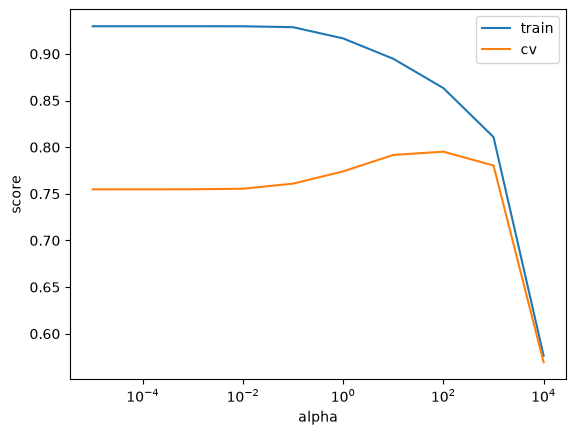

In [29]:
plt.semilogx(param_grid["ridge__alpha"], train_scores.tolist(), label="train")
plt.semilogx(param_grid["ridge__alpha"], cv_scores.tolist(), label="cv")
plt.legend()
plt.xlabel("alpha")
plt.ylabel("score");

In [30]:
best_alpha = search.best_params_
best_alpha

{'ridge__alpha': np.float64(100.0)}

In [31]:
search.best_score_

np.float64(0.7951559890417759)

- It seems alpha=100 is the best choice here.

- General intuition: larger `alpha` leads to smaller coefficients.
- Smaller coefficients mean the predictions are less sensitive to changes in the data. Hence less chance of overfitting.  

In [32]:
pipe_bigalpha = make_pipeline(preprocessor, Ridge(alpha=1000))
pipe_bigalpha.fit(X_train, y_train)
bigalpha_coeffs = pipe_bigalpha.named_steps["ridge"].coef_
pd.DataFrame(
    data=bigalpha_coeffs, index=new_columns, columns=["Coefficients"]
).sort_values(by="Coefficients", ascending=False)

,Coefficients
OverallQual,9691.378159
GrLivArea,7816.490033
1stFlrSF,5931.401623
TotRmsAbvGrd,5209.377032
GarageCars,5057.215412
...,...
SaleType_WD,-1214.532034
GarageFinish_Unf,-1281.596864
Foundation_CBlock,-1766.048889
RoofStyle_Gable,-1985.253914


- Smaller `alpha` leads to bigger coefficients. 

In [33]:
pipe_smallalpha = make_pipeline(preprocessor, Ridge(alpha=0.01))
pipe_smallalpha.fit(X_train, y_train)
smallalpha_coeffs = pipe_smallalpha.named_steps["ridge"].coef_
pd.DataFrame(
    data=smallalpha_coeffs, index=new_columns, columns=["Coefficients"]
).sort_values(by="Coefficients", ascending=False)

,Coefficients
RoofMatl_WdShngl,128384.117412
RoofMatl_Membran,127326.497786
RoofMatl_Metal,106023.481514
Condition2_PosA,83437.787574
RoofMatl_CompShg,70568.838951
...,...
Exterior1st_ImStucc,-34441.626206
Heating_OthW,-34806.290424
Condition2_RRAe,-63362.335309
Condition2_PosN,-194985.470060


With the best alpha found by the grid search, the coefficients are somewhere in between. 

In [34]:
pipe_bestalpha = make_pipeline(
    preprocessor, Ridge(alpha=search.best_params_["ridge__alpha"])
)
pipe_bestalpha.fit(X_train, y_train)
bestalpha_coeffs = pipe_bestalpha.named_steps["ridge"].coef_
pd.DataFrame(
    data=bestalpha_coeffs, index=new_columns, columns=["Coefficients"]
).sort_values(by="Coefficients", ascending=False)

,Coefficients
OverallQual,14485.526602
GrLivArea,11693.792577
Neighborhood_NridgHt,9661.926657
Neighborhood_NoRidge,9492.921850
BsmtQual,8076.988901
...,...
RoofMatl_ClyTile,-3991.413796
LandContour_Bnk,-5002.470666
Neighborhood_Gilbert,-5212.984664
Neighborhood_CollgCr,-5461.450739


To summarize: 
- Higher values of `alpha` means a more restricted model.  
- The values of coefficients are likely to be smaller for higher values of `alpha` compared to lower values of alpha. 

### Tuning with `RidgeCV`

Because tuning `alpha` is common, scikit-learn provides `RidgeCV`, which selects `alpha` using cross-validation.

In [35]:
alphas = 10.0 ** np.arange(-6, 6, 1)
ridgecv_pipe = make_pipeline(preprocessor, RidgeCV(alphas=alphas, cv=10))
ridgecv_pipe.fit(X_train, y_train);

In [36]:
best_alpha = ridgecv_pipe.named_steps["ridgecv"].alpha_

best_alpha

np.float64(100.0)

Let's examine the tuned model.

In [37]:
ridge_tuned = make_pipeline(preprocessor, Ridge(alpha=best_alpha))
ridge_tuned.fit(X_train, y_train)
ridge_preds = ridge_tuned.predict(X_test)
ridge_preds[:10]

array([228603.06797961, 104643.99931883, 155624.61029914, 246332.07245741,
       127614.33726089, 243243.60429913, 304784.87844893, 145425.67512181,
       157008.6526853 , 128528.91515735])

In [38]:
df = pd.DataFrame(
    data={"coefficients": ridge_tuned.named_steps["ridge"].coef_}, index=new_columns
)

In [39]:
df.sort_values("coefficients", ascending=False)

,coefficients
OverallQual,14485.526602
GrLivArea,11693.792577
Neighborhood_NridgHt,9661.926657
Neighborhood_NoRidge,9492.921850
BsmtQual,8076.988901
...,...
RoofMatl_ClyTile,-3991.413796
LandContour_Bnk,-5002.470666
Neighborhood_Gilbert,-5212.984664
Neighborhood_CollgCr,-5461.450739


So according to this model:

- As `OverallQual` feature gets bigger the housing price will get bigger.
- `Neighborhood_Edwards` is associated with reducing the housing price. 
    - We'll talk more about interpretation of different kinds of features next week.

In [40]:
ridge_preds.max(), ridge_preds.min()

(np.float64(390725.74720920826), np.float64(30815.28122025555))

### Exercise 10.1: Preprocessing and regularization

**Select all of the following statements which are TRUE.**

- (A) Price per square foot would be a good feature to add in our `X`. 
- (B) The `alpha` hyperparameter of `Ridge` has similar interpretation of `C` hyperparameter of `LogisticRegression`; higher `alpha` means more complex model. 
- (C) In `Ridge`, smaller alpha means bigger coefficients whereas bigger alpha means smaller coefficients.  

Can we use the metrics we looked at in the previous lecture for this problem? Why or why not? 

## Evaluating regression predictions

For classification, we could ask whether a predicted label matched the observed label. For house prices, exact equality is too strict: predicting \$301,000 for a house that sells for \$300,000 is a small error. We need metrics that account for the size of the errors.


- We aren't doing classification anymore, so we can't just check for equality:

In [41]:
ridge_tuned.predict(X_train) == y_train

302     False
767     False
429     False
1139    False
558     False
        ...  
1041    False
1122    False
1346    False
1406    False
1389    False
Name: SalePrice, Length: 1314, dtype: bool

In [42]:
y_train.values

array([205000, 160000, 175000, ..., 262500, 133000, 131000], shape=(1314,))

In [43]:
ridge_tuned.predict(X_train)

array([212870.41150573, 178494.22221894, 189981.34426571, ...,
       245329.56804591, 129904.71327467, 135422.67672595], shape=(1314,))

We need a score that reflects how right/wrong each prediction is.

There are a number of popular scoring functions for regression. We are going to look at some common metrics: 

- mean squared error (MSE)
- $R^2$
- root mean squared error (RMSE)
- MAPE

See [sklearn documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics) for more details. 

### Mean squared error (MSE)

- A common metric is mean squared error:

In [44]:
preds = ridge_tuned.predict(X_train)

In [45]:
np.mean((y_train - preds) ** 2)

np.float64(872961060.7986554)

Perfect predictions would have MSE=0.

In [46]:
np.mean((y_train - y_train) ** 2)

np.float64(0.0)

This is also implemented in sklearn:

In [47]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_train, preds)

872961060.7986554

- MSE looks huge and unreasonable. There is an error of ~\$1 Billion!
- Is this score good or bad?

- Unlike classification, with regression **our target has units**. 
- The target is in dollars, the mean squared error is in $dollars^2$ 
- The score also depends on the scale of the targets. 
- If we were working in cents instead of dollars, our MSE would be $10,000 \times (100^2$) higher!

In [48]:
np.mean((y_train * 100 - preds * 100) ** 2)

np.float64(8729610607986.554)

### Root mean squared error (RMSE)

MSE is in squared dollars. Taking its square root gives RMSE, which is in the same units as the target.

In [49]:
np.sqrt(mean_squared_error(y_train, ridge_tuned.predict(X_train)))

np.float64(29545.91445189428)

- Error of \$30,000 makes more sense.
- Let's dig deeper. 

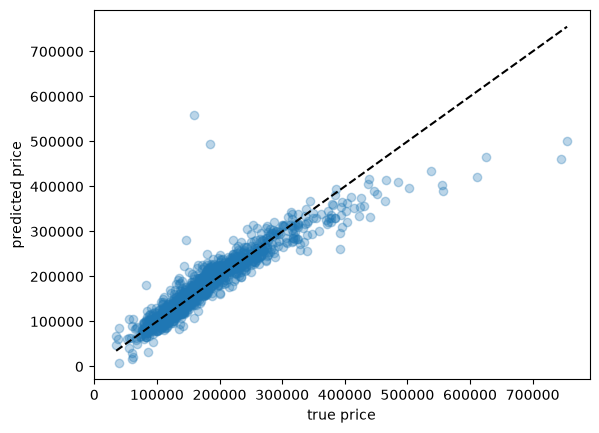

In [50]:
plt.scatter(y_train, ridge_tuned.predict(X_train), alpha=0.3)
grid = np.linspace(y_train.min(), y_train.max(), 1000)
plt.plot(grid, grid, "--k")
plt.xlabel("true price")
plt.ylabel("predicted price");

Each point compares a house’s observed price with its predicted price. Points above the dashed line represent overpredictions; points below it represent underpredictions. Because many points overlap, this plot alone does not clearly show whether overprediction or underprediction is more common. We can count each directly:


In [51]:
# Positive errors indicate overprediction; negative errors indicate underprediction.
errors = ridge_tuned.predict(X_train) - y_train
print(f"Overpredictions: {(errors > 0).mean():.1%}")
print(f"Underpredictions: {(errors < 0).mean():.1%}")
print(f"Exact matches: {(errors == 0).mean():.1%}")

Overpredictions: 52.1%
Underpredictions: 47.9%
Exact matches: 0.0%


These percentages describe how often the model predicts too high or too low on the training set, not how large those errors are. Even similar percentages can hide a few very large errors in one direction. RMSE summarizes error magnitude but does not tell us the direction of the errors.

### Coefficient of determination ($R^2$)

For the regressors used here, `.score()` returns $R^2$ by default. This metric compares squared prediction errors with the squared deviations of the observed targets from their mean. It is unitless and has a maximum of 1.

$$R^2(y, \hat{y}) = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y_i})^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$

The numerator sums the squared prediction errors. The denominator sums the squared deviations from the mean of the targets in the evaluation set.

A perfect prediction has $R^2=1$. A value of 0 matches predicting the mean of the evaluation targets; a negative value is worse than that reference. This reference is not necessarily the same as a `DummyRegressor` fitted on a separate training set.

(Optional) Warning: MSE is "reversible" but $R^2$ is not:

In [52]:
mean_squared_error(y_train, preds)

872961060.7986554

In [53]:
mean_squared_error(preds, y_train)

872961060.7986554

In [54]:
r2_score(y_train, preds)

0.860164385444608

In [55]:
r2_score(preds, y_train)

0.8280229354283178

The metric used to evaluate a model and the objective used to fit it are distinct choices. Ridge regression fits coefficients using squared error plus a regularization penalty; changing the evaluation metric does not change that fitting objective.

### Mean absolute percentage error (MAPE)

We obtained an RMSE of roughly \$30,000. Is an error of that size acceptable?

In [56]:
np.sqrt(mean_squared_error(y_train, ridge_tuned.predict(X_train)))

np.float64(29545.91445189428)

- For a house worth \$600k, it seems reasonable! That's 5% error.
- For a house worth \$60k, that is terrible. It's 50% error.

We have both of these cases in our dataset.

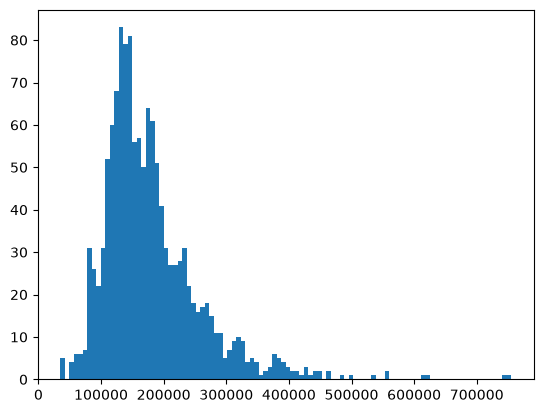

In [57]:
plt.hist(y_train, bins=100);

How about looking at percent error? 

In [58]:
pred_train = ridge_tuned.predict(X_train)
percent_errors = (pred_train - y_train) / y_train * 100.0
percent_errors

302      3.839225
767     11.558889
429      8.560768
1139   -16.405650
558     17.194710
          ...    
1041    -0.496213
1122   -28.624615
1346    -6.541117
1406    -2.327283
1389     3.376089
Name: SalePrice, Length: 1314, dtype: float64

These are both positive (predict too high) and negative (predict too low).

We can look at the absolute percent error:

In [59]:
np.abs(percent_errors)

302      3.839225
767     11.558889
429      8.560768
1139    16.405650
558     17.194710
          ...    
1041     0.496213
1122    28.624615
1346     6.541117
1406     2.327283
1389     3.376089
Name: SalePrice, Length: 1314, dtype: float64

And, like MSE, we can take the average over examples. This is called mean absolute percent error (MAPE).

In [60]:
def my_mape(true, pred):
    return np.mean(np.abs((pred - true) / true))

In [61]:
my_mape(y_train, pred_train)

np.float64(0.1009266520343875)

Let's use `sklearn` to calculate MAPE. 

In [62]:
from sklearn.metrics import mean_absolute_percentage_error

In [63]:
mean_absolute_percentage_error(y_train, pred_train)

0.1009266520343875

A MAPE near 0.10 corresponds to an average absolute percentage error near 10%. Scikit-learn returns a proportion, so multiply by 100 to express it as a percentage.

MAPE needs care when true targets are zero or close to zero, because division by a small target can produce very large errors.

### Using metrics in cross-validation

Let’s evaluate the ridge pipeline using MSE instead of its default $R^2$ score. Scikit-learn scorers follow a higher-is-better convention, so error metrics use negative scores: a value closer to zero is better.

In [64]:
pd.DataFrame(
    cross_validate(
        ridge_tuned,
        X_train,
        y_train,
        return_train_score=True,
        scoring="neg_mean_squared_error",
    )
)

,fit_time,score_time,test_score,train_score
0,0.015908,0.004711,-7.055915e+08,-9.379875e+08
1,0.014114,0.004513,-1.239944e+09,-8.264283e+08
2,0.013492,0.004409,-1.125440e+09,-8.758062e+08
3,0.013725,0.004605,-9.801219e+08,-8.849438e+08
4,0.013276,0.004349,-2.267612e+09,-7.395282e+08


In [65]:
# make a scorer function that we can pass into cross-validation
mape_scorer = make_scorer(my_mape, greater_is_better=False)

pd.DataFrame(
    cross_validate(
        ridge_tuned, X_train, y_train, return_train_score=True, scoring=mape_scorer
    )
)

,fit_time,score_time,test_score,train_score
0,0.015512,0.004490,-0.096960,-0.104070
1,0.013432,0.004683,-0.107985,-0.099685
2,0.013349,0.004268,-0.118347,-0.101796
3,0.013328,0.004426,-0.107947,-0.102435
4,0.013353,0.004473,-0.121985,-0.098307


If you are finding `greater_is_better=False` argument confusing, here is the documentation: 

> greater_is_better(bool), default=True
Whether score_func is a score function (default), meaning high is good, or a loss function, meaning low is good. In the latter case, the scorer object will sign-flip the outcome of the score_func.

Since our custom scorer `mape` gives an error and not a score, I'm passing `False` to it and it'll sign flip so that we can interpret bigger numbers as better performance.  

In [66]:
# ?make_scorer

In [67]:
scoring = {
    "r2": "r2",
    "mape_scorer": mape_scorer, # just for demonstration for a custom scorer
    "sklearn MAPE": "neg_mean_absolute_percentage_error",
    "neg_root_mean_square_error": "neg_root_mean_squared_error",
    "neg_mean_squared_error": "neg_mean_squared_error",
}

pd.DataFrame(
    cross_validate(
        ridge_tuned, X_train, y_train, return_train_score=True, scoring=scoring
    )
).T

,0,1,2,3,4
fit_time,1.532912e-02,1.336908e-02,2.002621e-02,1.341701e-02,1.336503e-02
score_time,5.092144e-03,5.143166e-03,8.215904e-03,5.386114e-03,5.084991e-03
test_r2,8.669805e-01,8.200326e-01,8.262156e-01,8.514598e-01,6.110915e-01
train_r2,8.551862e-01,8.636849e-01,8.580539e-01,8.561645e-01,8.834356e-01
test_mape_scorer,-9.696034e-02,-1.079852e-01,-1.183471e-01,-1.079471e-01,-1.219845e-01
train_mape_scorer,-1.040698e-01,-9.968514e-02,-1.017959e-01,-1.024351e-01,-9.830712e-02
test_sklearn MAPE,-9.696034e-02,-1.079852e-01,-1.183471e-01,-1.079471e-01,-1.219845e-01
train_sklearn MAPE,-1.040698e-01,-9.968514e-02,-1.017959e-01,-1.024351e-01,-9.830712e-02
test_neg_root_mean_square_error,-2.656297e+04,-3.521284e+04,-3.354759e+04,-3.130690e+04,-4.761945e+04
train_neg_root_mean_square_error,-3.062658e+04,-2.874767e+04,-2.959402e+04,-2.974801e+04,-2.719427e+04


Are we getting the same `alpha` with mape? 

In [68]:
param_grid = {"ridge__alpha": 10.0 ** np.arange(-6, 6, 1)}

pipe_ridge = make_pipeline(preprocessor, Ridge())

search = GridSearchCV(
    pipe_ridge, param_grid, return_train_score=True, n_jobs=-1, scoring=mape_scorer
)
search.fit(X_train, y_train);

In [69]:
print("Best hyperparameter values: ", search.best_params_)
print("Best score: %0.3f" % (search.best_score_))
pd.DataFrame(search.cv_results_)[
    [
        "mean_train_score",
        "mean_test_score",
        "param_ridge__alpha",
        "mean_fit_time",
        "rank_test_score",
    ]
].set_index("rank_test_score").sort_index().T

Best hyperparameter values:  {'ridge__alpha': np.float64(100.0)}
Best score: -0.111


rank_test_score,1,2,3,4,5,6,7,8,9,10,11,12
mean_train_score,-0.101259,-0.111543,-0.096462,-0.090785,-0.085698,-0.085508,-0.085546,-0.085550,-0.085551,-0.085551,-0.203421,-0.33213
mean_test_score,-0.110645,-0.115401,-0.116497,-0.122331,-0.125644,-0.127242,-0.127418,-0.127439,-0.127441,-0.127441,-0.204692,-0.33271
param_ridge__alpha,100.000000,1000.000000,10.000000,1.000000,0.100000,0.010000,0.001000,0.000100,0.000010,0.000001,10000.000000,100000.00000
mean_fit_time,0.025153,0.023427,0.024250,0.025009,0.025574,0.024613,0.023947,0.020550,0.018117,0.017137,0.023899,0.02538


### Selecting a model with multiple metrics

We can evaluate multiple metrics in `GridSearchCV` or `RandomizedSearchCV`. Set `refit` to the name of the metric used to select the best candidate and refit it on all the training data passed to the search.

In [70]:
search_multi = GridSearchCV(
    pipe_ridge,
    param_grid,
    return_train_score=True,
    n_jobs=-1,
    scoring=scoring,
    refit="sklearn MAPE",
)
search_multi.fit(X_train, y_train);

In [71]:
print("Best hyperparameter values: ", search_multi.best_params_)
print("Best score: %0.3f" % (search_multi.best_score_))
pd.DataFrame(search_multi.cv_results_).set_index("rank_test_mape_scorer").sort_index()

Best hyperparameter values:  {'ridge__alpha': np.float64(100.0)}
Best score: -0.111


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ridge__alpha,params,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,...,mean_test_neg_mean_squared_error,std_test_neg_mean_squared_error,rank_test_neg_mean_squared_error,split0_train_neg_mean_squared_error,split1_train_neg_mean_squared_error,split2_train_neg_mean_squared_error,split3_train_neg_mean_squared_error,split4_train_neg_mean_squared_error,mean_train_neg_mean_squared_error,std_train_neg_mean_squared_error
rank_test_mape_scorer,,,,,,,,,,,,,,,,,,,,,
1,0.020100,0.001228,0.007911,0.001097,100.000000,{'ridge__alpha': 100.0},0.866980,0.820033,0.826216,0.851460,...,-1.263742e+09,5.328077e+08,1,-9.379875e+08,-8.264283e+08,-8.758062e+08,-8.849438e+08,-7.395282e+08,-8.529388e+08,6.685103e+07
2,0.020386,0.000784,0.007684,0.000926,1000.000000,{'ridge__alpha': 1000.0},0.827261,0.786555,0.802902,0.812272,...,-1.362185e+09,3.262269e+08,3,-1.282021e+09,-1.156311e+09,-1.207814e+09,-1.225301e+09,-1.029950e+09,-1.180279e+09,8.521743e+07
3,0.021600,0.001725,0.008285,0.000252,10.000000,{'ridge__alpha': 10.0},0.859318,0.820564,0.832866,0.846650,...,-1.283119e+09,5.511620e+08,2,-7.034979e+08,-6.276943e+08,-6.910456e+08,-6.701186e+08,-5.915714e+08,-6.567856e+08,4.155178e+07
4,0.021053,0.001887,0.008243,0.000982,1.000000,{'ridge__alpha': 1.0},0.835749,0.810073,0.831611,0.843992,...,-1.386071e+09,6.378971e+08,4,-5.394113e+08,-4.898703e+08,-5.405227e+08,-5.290961e+08,-5.046193e+08,-5.207039e+08,2.011269e+07
5,0.021760,0.001661,0.008532,0.001030,0.100000,{'ridge__alpha': 0.1},0.821807,0.792828,0.805198,0.863941,...,-1.465279e+09,6.931439e+08,5,-4.579559e+08,-4.009514e+08,-4.345386e+08,-4.515351e+08,-4.846260e+08,-4.459214e+08,2.766317e+07
6,0.024136,0.001052,0.008755,0.001759,0.010000,{'ridge__alpha': 0.01},0.824884,0.782183,0.787933,0.868003,...,-1.501304e+09,7.090376e+08,6,-4.522563e+08,-3.926733e+08,-4.251158e+08,-4.446284e+08,-4.837022e+08,-4.396752e+08,3.014081e+07
7,0.021776,0.001010,0.009373,0.000732,0.001000,{'ridge__alpha': 0.001},0.826553,0.780497,0.785399,0.868281,...,-1.505592e+09,7.117899e+08,7,-4.521578e+08,-3.925288e+08,-4.249618e+08,-4.445124e+08,-4.836880e+08,-4.395697e+08,3.018459e+07
8,0.021669,0.001621,0.008141,0.000802,0.000100,{'ridge__alpha': 0.0001},0.826739,0.780316,0.785134,0.868305,...,-1.506035e+09,7.120769e+08,8,-4.521567e+08,-3.925272e+08,-4.249601e+08,-4.445111e+08,-4.836878e+08,-4.395686e+08,3.018507e+07
9,0.020670,0.001364,0.008416,0.000983,0.000010,{'ridge__alpha': 1e-05},0.826758,0.780298,0.785108,0.868308,...,-1.506079e+09,7.121056e+08,9,-4.521567e+08,-3.925272e+08,-4.249601e+08,-4.445111e+08,-4.836878e+08,-4.395686e+08,3.018507e+07


What's the test score? 

In [72]:
search_multi.score(X_test, y_test)

-0.09503409246217508

In [73]:
my_mape(y_test, ridge_tuned.predict(X_test))

np.float64(0.09503409246217508)

::: {.callout-note}
Metric functions such as `mean_squared_error` return nonnegative errors. Scoring names such as `"neg_mean_squared_error"` return their negatives so that larger scores indicate better performance.
:::

### Exercise 10.2: Interpreting regression metrics

**Select all of the following statements which are TRUE.**

- (A) We can use still use precision and recall for regression problems but now we have other metrics we can use as well.
- (B) In `sklearn` for regression problems, using `r2_score()` and `.score()` (with default values) will produce the same results.
- (C) RMSE is always going to be non-negative.
- (D) MSE does not directly provide the information about whether the model is underpredicting or overpredicting.
- (E) We can pass multiple scoring metrics to `GridSearchCV` or `RandomizedSearchCV` for regression as well as classification problems. 


## Transforming the target

So far, preprocessing has changed the input features while leaving sale prices in dollars. We can also transform the target before fitting a model, then undo that transformation when making predictions. House prices provide a useful example because their range is wide and their distribution is skewed.

### Examining the target distribution

Let’s inspect the distribution of sale prices in the training set.

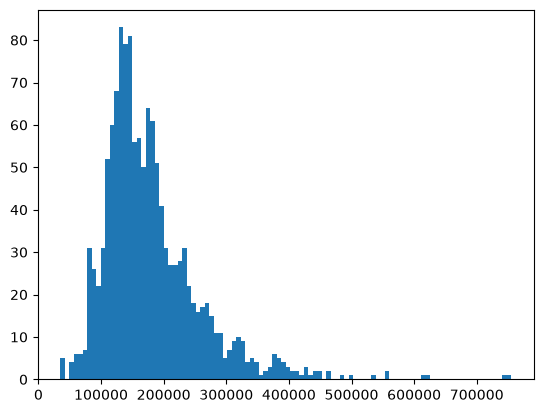

In [74]:
plt.hist(y_train, bins=100);

A log transformation compresses large values more than small ones. This can be useful when relative differences matter. A less skewed target distribution alone does not guarantee a better model; we still need to evaluate the resulting predictions.

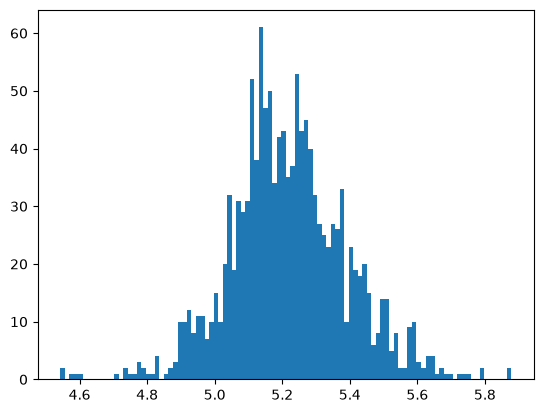

In [75]:
plt.hist(np.log10(y_train), bins=100);

### Fitting with `TransformedTargetRegressor`

`TransformedTargetRegressor` applies a transformation to the training targets and the inverse transformation to predictions. Our model below uses `log1p` and its inverse, `expm1`.

In [76]:
from sklearn.compose import TransformedTargetRegressor

In [77]:
ttr = TransformedTargetRegressor(
    Ridge(alpha=best_alpha), func=np.log1p, inverse_func=np.expm1
) # transformer for log transforming the target
ttr_pipe = make_pipeline(preprocessor, ttr)

In [78]:
ttr_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('transformedtargetregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('drop', ...), ('pipeline-1', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and `

Why can't we incorporate preprocessing targets in our column transformer? 

In [79]:
ttr_pipe.fit(X_train, y_train); # y_train automatically transformed

In [80]:
ttr_pipe.predict(X_train)  # predictions automatically un-transformed

array([221329.43833466, 170670.12761659, 182639.31984311, ...,
       248609.60023631, 132158.15026771, 133270.71866979], shape=(1314,))

In [81]:
mean_absolute_percentage_error(y_test, ttr_pipe.predict(X_test))

0.07808506982896293

This reports test-set MAPE for the transformed-target model. The earlier MAPE near 10% was measured on the training set, so those two values do not establish an improvement. A comparison of the approaches should use the same held-out examples or cross-validation splits.

::: {.callout-reflection}
Does `.fit()` know that we care about MAPE? Explain how changing the target scale differs from changing the scoring metric used in model selection.
:::

The wrapped ridge model still fits using squared error plus regularization, now on the transformed target scale. This reduces the dominance of large dollar differences, but it does not directly minimize MAPE.

## Chapter summary

The house prices example combines preprocessing decisions with model fitting and evaluation. Feature meanings guide their encodings; ridge regression’s `alpha` controls regularization; and the evaluation metric determines how we compare predictions.

| Metric | Interpretation | Units | Best value |
|---|---|---|---|
| MSE | Mean squared prediction error | Target units squared | 0 |
| RMSE | Square root of MSE | Target units | 0 |
| $R^2$ | Squared-error performance relative to the evaluation-target mean | Unitless | 1 |
| MAPE | Mean absolute error relative to each observed target | Proportion | 0 |

Choose a metric that reflects the errors that matter in the application. Use it consistently when comparing candidates. Transforming the target changes the fitting problem, so evaluate whether it helps on the original prediction scale.